# EDA — Developer Salary Survey

Two passes over the same data:

- **Pass A** looks at `data/survey.csv` completely raw, before any cleaning code is
  written. The goal is to let each chart justify a specific decision in
  `src/data_prep.py`, instead of asserting the cleaning logic from memory.
- **Pass B** re-runs the same kind of analysis after calling `load_and_clean()`, to
  check the cleaning did what it was supposed to and to look at correlation /
  categorical association for feature selection going into modeling.


In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

sys.path.insert(0, "../src")
from data_prep import cramers_v, load_and_clean

# Palette: fixed categorical hues + a blue-red diverging pair + a blue
# sequential ramp, per this project's dataviz convention.
BLUE = "#2a78d6"
ORANGE = "#eb6834"
GRAY_MID = "#f0efec"
RED = "#e34948"

DIVERGING = LinearSegmentedColormap.from_list("diverging", [RED, GRAY_MID, BLUE])
SEQUENTIAL = LinearSegmentedColormap.from_list("sequential", [GRAY_MID, BLUE])

plt.rcParams["figure.facecolor"] = "white"


## Pass A — raw data, before any cleaning

In [2]:
raw = pd.read_csv("../data/survey.csv")
raw.shape


(5000, 16)

### Target distribution — is it skewed?

pandas already reads the literal `"NA"` strings as real `NaN` on load (it's one of
pandas' default null tokens), so `.dropna()` here is enough to isolate the rows
that actually answered the salary question.


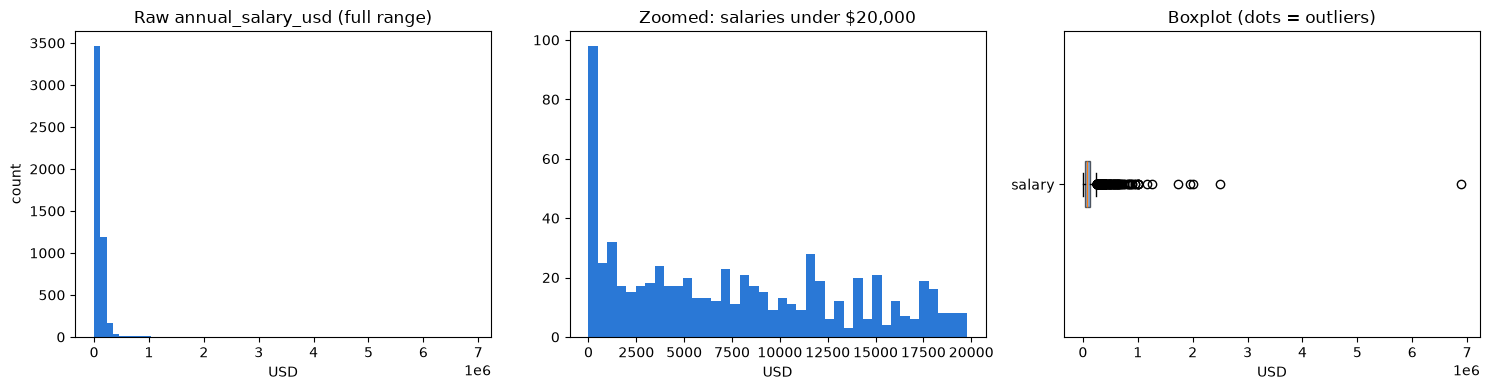

count    4.916000e+03
mean     9.835268e+04
std      1.454344e+05
min      1.000000e+00
25%      4.176500e+04
50%      7.755900e+04
75%      1.239930e+05
max      6.890299e+06
Name: annual_salary_usd, dtype: float64

rows under $1,000: 124
rows over $1,000,000: 8


In [3]:
salary_raw = raw["annual_salary_usd"].dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(salary_raw, bins=60, color=BLUE)
axes[0].set_title("Raw annual_salary_usd (full range)")
axes[0].set_xlabel("USD")
axes[0].set_ylabel("count")

axes[1].hist(salary_raw[salary_raw < 20_000], bins=40, color=BLUE)
axes[1].set_title("Zoomed: salaries under $20,000")
axes[1].set_xlabel("USD")

bp = axes[2].boxplot(
    salary_raw, orientation="horizontal", patch_artist=True, tick_labels=["salary"]
)
for box in bp["boxes"]:
    box.set_facecolor(BLUE)
    box.set_alpha(0.6)
axes[2].set_title("Boxplot (dots = outliers)")
axes[2].set_xlabel("USD")

plt.tight_layout()
plt.show()

print(salary_raw.describe())
print()
print(f"rows under $1,000: {(salary_raw < 1_000).sum()}")
print(f"rows over $1,000,000: {(salary_raw > 1_000_000).sum()}")


**Reading these charts:** the full-range histogram is unreadable — almost
everything is crushed into the first bar by a handful of multi-million-dollar
entries. The zoomed view shows a real cluster of "salaries" under a few hundred
dollars, which isn't plausible annual pay for a professional developer (more likely
an hourly rate typed into the wrong field, or a joke answer). The boxplot's dots
confirm a long right tail well past what a normal salary distribution should look
like.

**Decision this drives:** these extreme values need handling, but *not* a fixed
global drop in `data_prep.py` — that would apply the same bounds to every row
regardless of which train/test/val split it lands in later, which is a subtle
leakage risk once we're evaluating a model. Instead, the modeling notebook
(`02_modeling.ipynb`) computes a floor/cap from the training split's own 5th/95th
percentiles only, winsorizes (clips) salaries outside that range, and adds a
binary flag marking which rows were touched — so the "extreme" threshold is
never informed by data the model will later be evaluated against. The
remaining right skew is real either way and gets handled with `log1p`.


### Missingness across every column

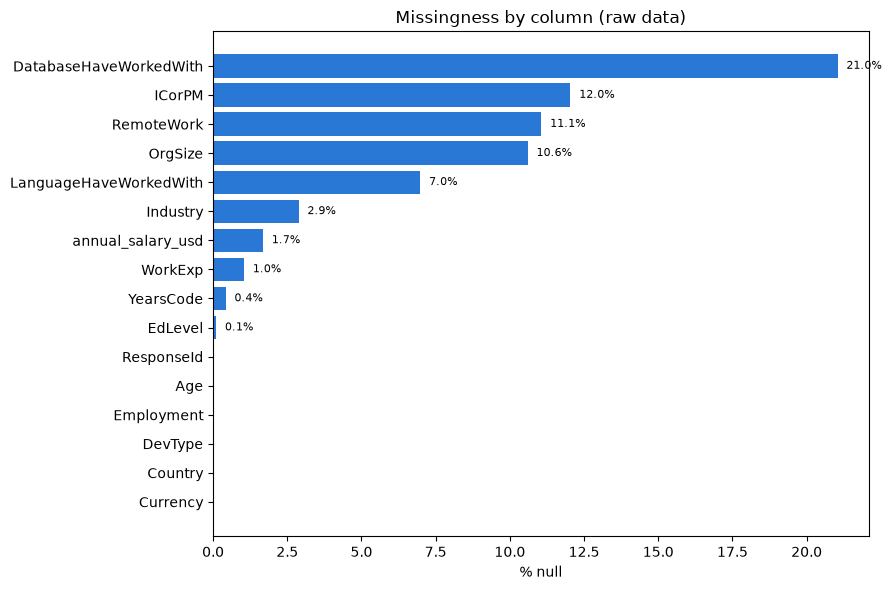

DatabaseHaveWorkedWith    21.04
ICorPM                    12.04
RemoteWork                11.06
OrgSize                   10.60
LanguageHaveWorkedWith     6.98
Industry                   2.88
annual_salary_usd          1.68
WorkExp                    1.04
YearsCode                  0.42
EdLevel                    0.10
dtype: float64

In [4]:
null_rate = (raw.isna().mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(null_rate.index[::-1], null_rate.values[::-1], color=BLUE)
ax.set_xlabel("% null")
ax.set_title("Missingness by column (raw data)")
for i, v in enumerate(null_rate.values[::-1]):
    if v > 0:
        ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()

null_rate[null_rate > 0]


**Reading this chart:** `ICorPM`, `OrgSize`, and `RemoteWork` are all above 10%
null — too much of the dataset to throw away, and plausibly informative on their
own (e.g. a freelancer has no "org size"). `WorkExp`/`YearsCode`/`EdLevel` are
under 1.5% null — small enough that simple handling (coercion, leaving `NaN` for
tree models) is fine. `annual_salary_usd` at 1.7% null just gets dropped, since
there's nothing to predict for those rows.

**Decision this drives:** `FILL_UNKNOWN_COLS` in `constants.py` fills the
double-digit-percent-null categoricals with an explicit `"Unknown"` category
rather than dropping rows or silently imputing a mode.


### Categorical distributions

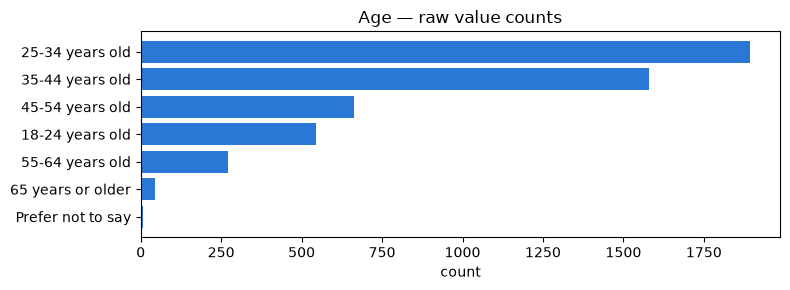

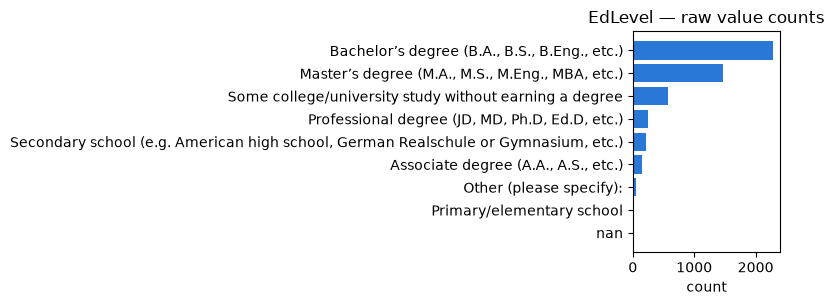

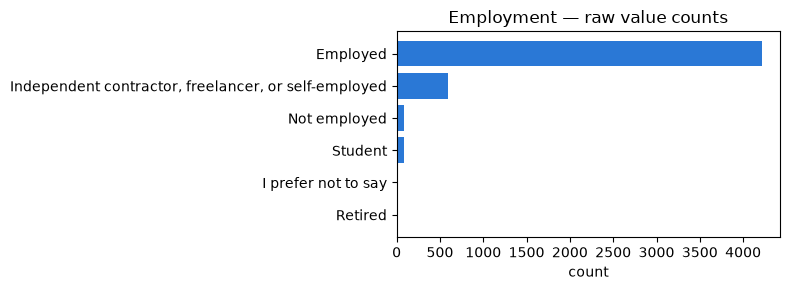

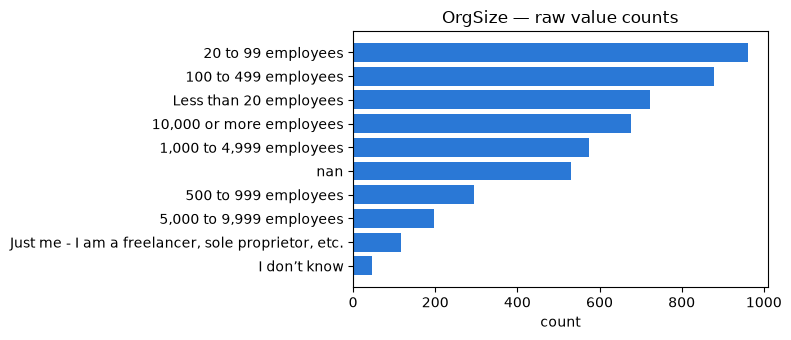

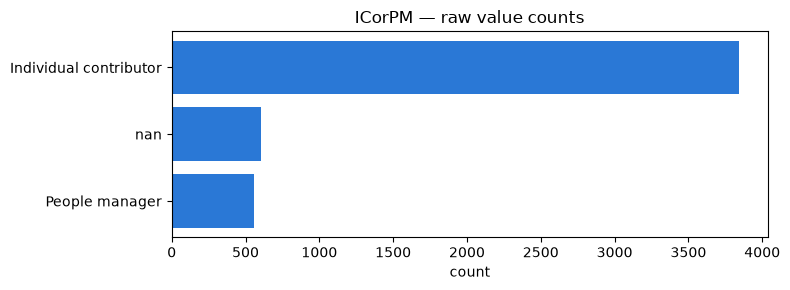

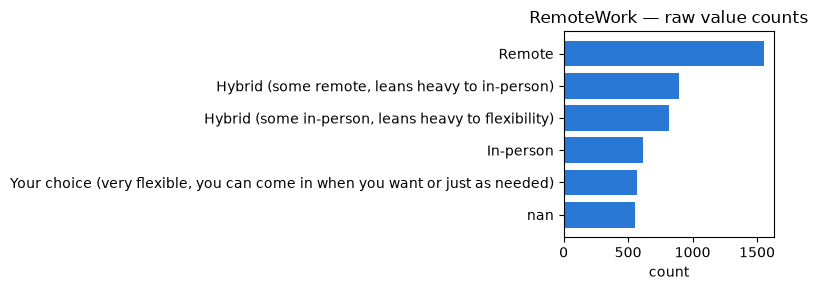

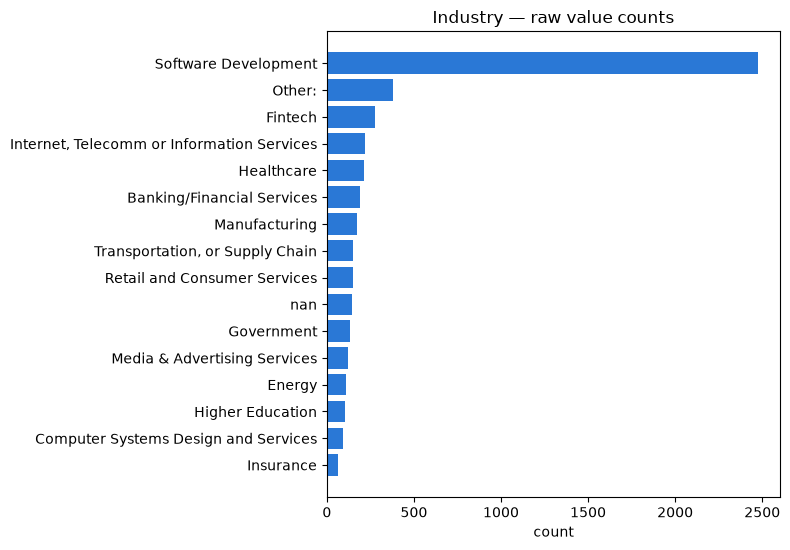

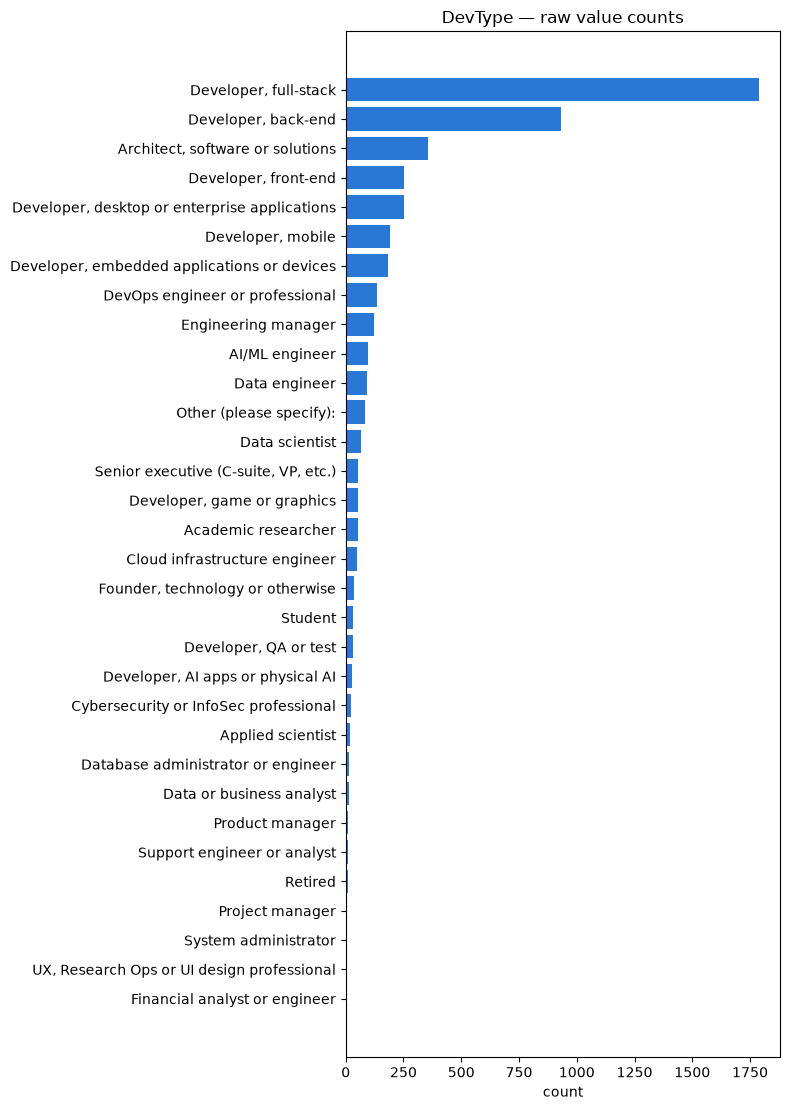

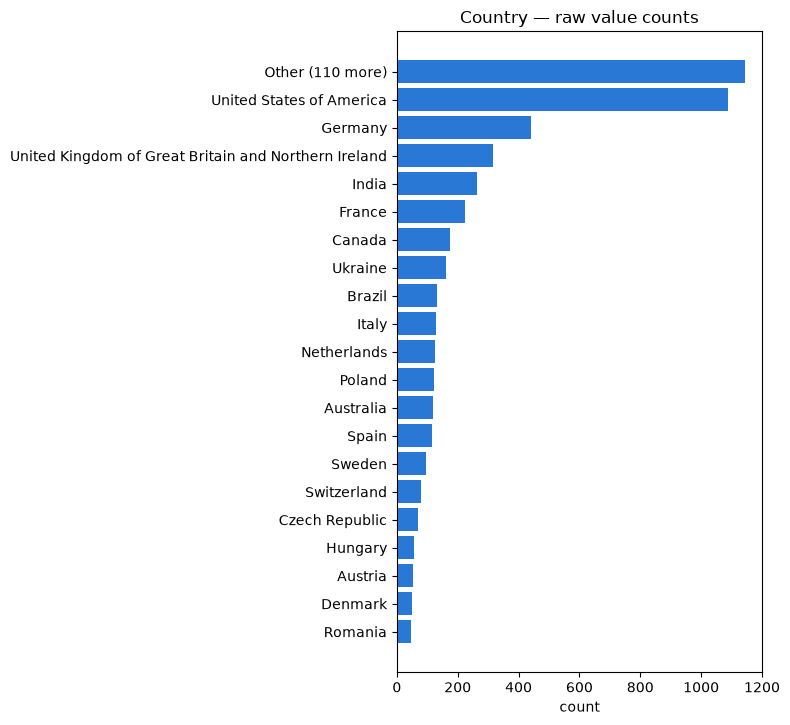

In [5]:
def plot_value_counts(series, title, top_n=None, ax=None):
    counts = series.value_counts(dropna=False)
    if top_n is not None and len(counts) > top_n:
        other_count = counts.iloc[top_n:].sum()
        n_more = len(counts) - top_n
        counts = counts.iloc[:top_n]
        counts[f"Other ({n_more} more)"] = other_count
    counts = counts.sort_values(ascending=True)
    if ax is None:
        _, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(counts))))
    ax.barh([str(x) for x in counts.index], counts.values, color=BLUE)
    ax.set_title(title)
    ax.set_xlabel("count")
    plt.tight_layout()
    return ax


for col, top_n in [
    ("Age", None),
    ("EdLevel", None),
    ("Employment", None),
    ("OrgSize", None),
    ("ICorPM", None),
    ("RemoteWork", None),
    ("Industry", None),
    ("DevType", None),
    ("Country", 20),
]:
    plot_value_counts(raw[col], f"{col} — raw value counts", top_n=top_n)
    plt.show()


**Reading these charts:** `Age` and `OrgSize` are clearly ordinal buckets
("25-34 years old", "20 to 99 employees"), not free categories — a plain one-hot
encoding would throw away the ordering. `Country` has 130 distinct values with a
long tail (the chart caps at the top 20 + an "Other" bar) and `DevType` has 32 —
both need a cardinality-reduction strategy for the ElasticNet baseline. `Industry`
has its own `"Other:"` catch-all already built into the survey.

**Decisions this drives:** `age_to_midpoint`/`orgsize_to_midpoint` in
`data_prep.py` convert the buckets to numeric midpoints (keeping the original
string too, for tree models); `TOP_N_COUNTRIES`/`TOP_N_DEVTYPES`/
`TOP_N_LANGUAGES`/`TOP_N_DATABASES` in `constants.py` cap cardinality by folding
the long tail into `"Other"` — sized per column by actual row/token coverage
rather than one arbitrary number for all four (`Country` needed a bigger N than
`DevType` to avoid losing too much to "Other" — see the comment in
`constants.py` for the coverage numbers behind each choice).


### One targeted check: `Country` vs `Currency` redundancy

Both are free-text-ish categoricals in the raw data with no nulls. If they're
carrying almost the same information, keeping both is pure multicollinearity —
this checks that directly with Cramér's V before deciding.


In [6]:
cv_country_currency = cramers_v(raw["Country"], raw["Currency"])
print(f"Cramér's V(Country, Currency) = {cv_country_currency:.3f}")
print(f"unique countries: {raw['Country'].nunique()}, unique currencies: {raw['Currency'].nunique()}")


Cramér's V(Country, Currency) = 0.905
unique countries: 130, unique currencies: 97


**Decision this drives:** a high Cramér's V here means `Country` and `Currency`
are telling us almost the same thing (which country you're in implies which
currency you're paid in, roughly). `load_and_clean()` drops `Currency` and keeps
`Country` (grouped to top-N + "Other") — `Country` is the more granular/useful
signal, and the target is already USD-normalized so currency-of-payment doesn't
add independent information about cost of living.


## Pass B — after `load_and_clean()`

In [7]:
clean = load_and_clean("../data/survey.csv")
clean.shape


(4916, 54)

### Target distribution, log-transformed

`load_and_clean()` doesn't touch salary values at all (only drops the 84 rows
with no salary), so `clean["annual_salary_usd"]` is the same distribution as
Pass A's `salary_raw` — this is just checking that, and looking at the log1p
shape on its own. The winsorize+flag step that actually bounds the extreme
tails is split-aware and happens later, in `02_modeling.ipynb`.


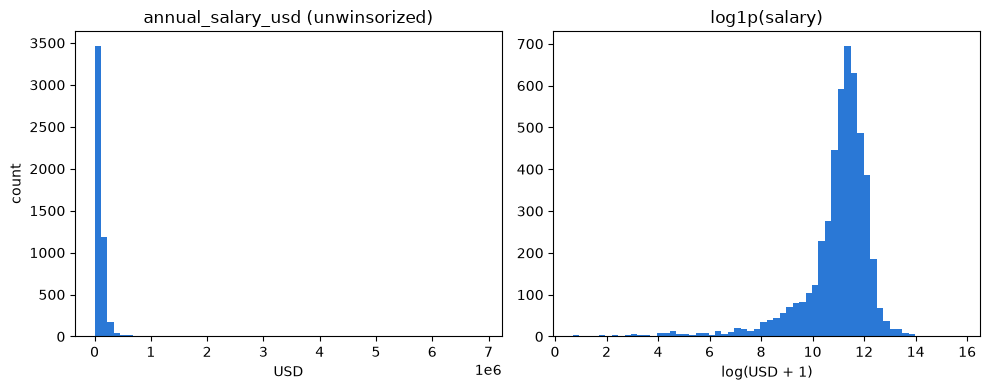

In [8]:
# Confirms load_and_clean() didn't touch salary values (only dropped null-target rows).
assert (clean["annual_salary_usd"].sort_values().values == salary_raw.sort_values().values).all()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(clean["annual_salary_usd"], bins=60, color=BLUE)
axes[0].set_title("annual_salary_usd (unwinsorized)")
axes[0].set_xlabel("USD")
axes[0].set_ylabel("count")

axes[1].hist(clean["log_salary"], bins=60, color=BLUE)
axes[1].set_title("log1p(salary)")
axes[1].set_xlabel("log(USD + 1)")

plt.tight_layout()
plt.show()


**Reading this:** still heavily right-skewed in dollars — expected, since no
outlier handling has happened yet at this stage. The log1p version looks much
closer to normal, which is why the modeling target is defined in log space
either way; the winsorize+flag step later addresses the small number of
extreme points that even the log transform doesn't fully tame.


### Numeric correlation heatmap (Pearson)

Only meaningful for the actual numeric columns — this is deliberately not run on
one-hot-encoded categoricals, since Pearson correlation between binary dummy
columns is a poor proxy for categorical association (that's what the Cramér's V
heatmap below is for).


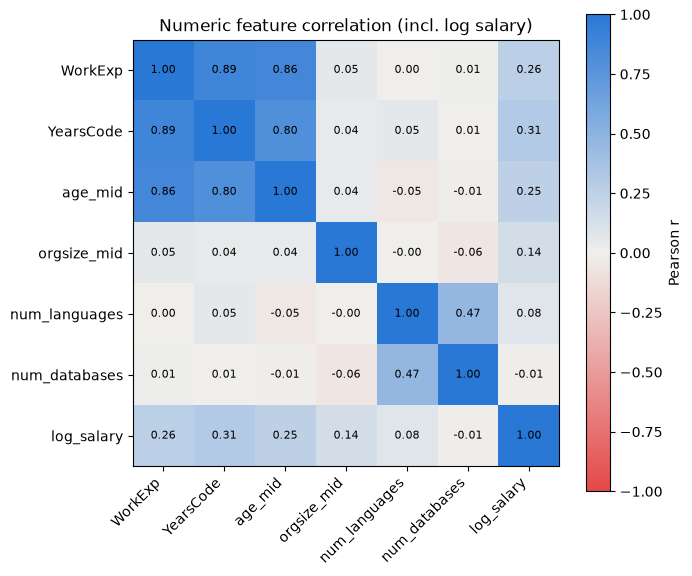

In [9]:
numeric_cols = [
    "WorkExp",
    "YearsCode",
    "age_mid",
    "orgsize_mid",
    "num_languages",
    "num_databases",
    "log_salary",
]
corr = clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
ax.set_yticks(range(len(numeric_cols)))
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Numeric feature correlation (incl. log salary)")
plt.tight_layout()
plt.show()


**Reading this:** look for (a) which numeric features correlate most with
`log_salary` — the strongest candidates for the ElasticNet baseline — and (b)
which numeric features correlate strongly with *each other* (a likely case is
`WorkExp` vs `YearsCode`, since they're both proxies for seniority) — a
multicollinearity pair worth watching in the linear model, even though tree
models don't care about it the same way.


### Is the relationship with each numeric feature actually linear?

A caveat on the heatmap above: Pearson's `r` only measures *linear* association
— two variables can have a weak/moderate `r` while still having a strong
non-linear relationship the correlation number completely hides. Before
committing to a linear functional form for these six features in ElasticNet,
worth actually looking at the shape.

Raw scatter at ~4,900 points is usually just a dense blob, so each panel below
also plots the mean `log_salary` per x-quantile-bin as a line — the standard way
to make a functional-form pattern visible through the noise.


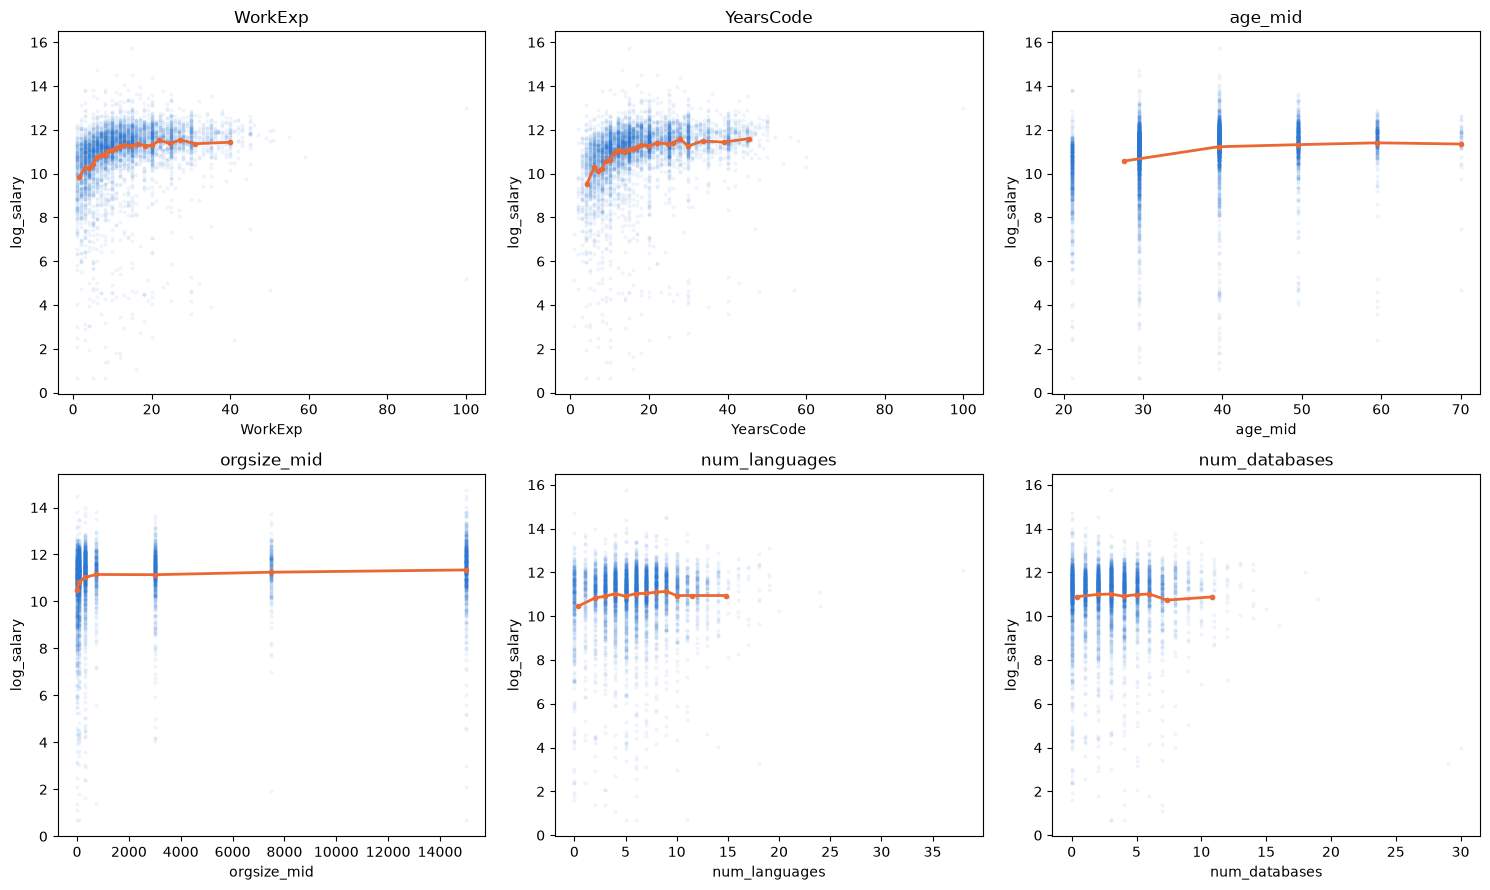

In [10]:
def plot_numeric_vs_target(df, col, target="log_salary", bins=25, ax=None):
    valid = df[[col, target]].dropna()
    q_bins = pd.qcut(valid[col], q=bins, duplicates="drop")
    binned = valid.groupby(q_bins, observed=True)[[col, target]].mean()

    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(valid[col], valid[target], s=4, alpha=0.05, color=BLUE)
    ax.plot(binned[col], binned[target], color=ORANGE, linewidth=2, marker="o", markersize=3)
    ax.set_xlabel(col)
    ax.set_ylabel(target)
    return ax


fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(
    axes.flat,
    ["WorkExp", "YearsCode", "age_mid", "orgsize_mid", "num_languages", "num_databases"],
):
    plot_numeric_vs_target(clean, col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Reading this:** the orange line is the actual shape (blue scatter is just
density context) — a straight, roughly diagonal line means ElasticNet's linear
term is already a good fit; a curve that bends (rises then flattens, or flattens
then rises) means the linear term alone will under-fit that feature and it's a
candidate for a squared term or a different transform before modeling.


### Salary by category (Pearson heatmap can't show this)

Box plots of `log_salary` (log scale keeps the boxes readable — the extreme
tails haven't been winsorized yet at this stage, so a handful of very high/low
points will still show as far-out fliers) by category, capped to the top
categories by row count so the boxes stay statistically meaningful.


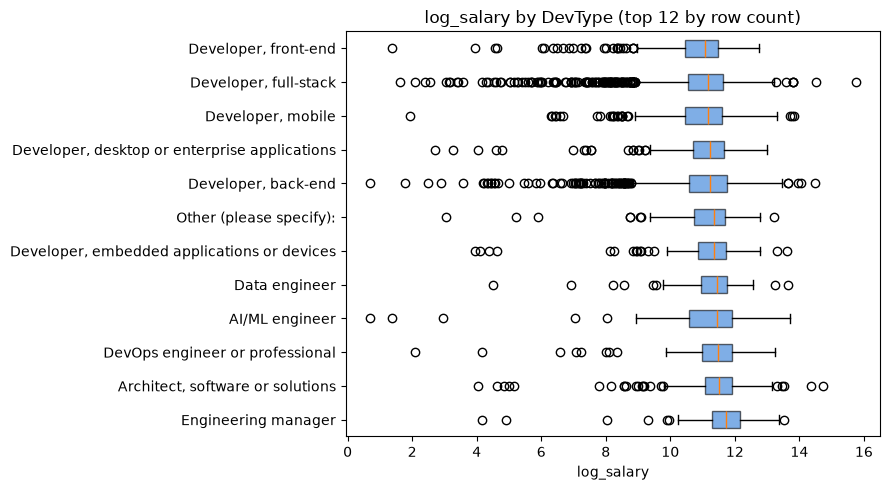

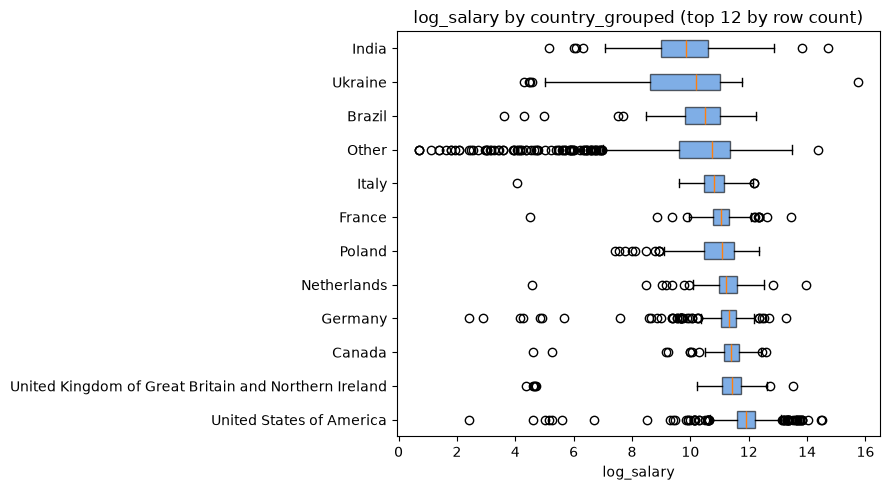

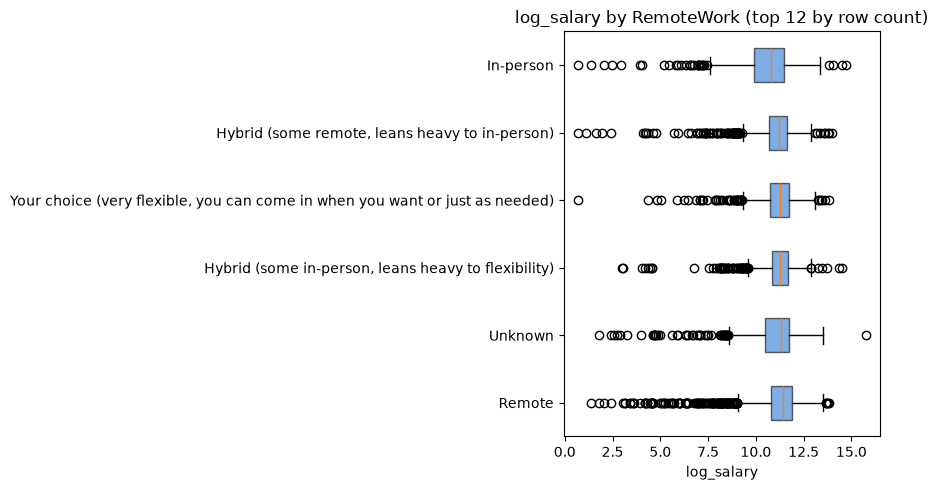

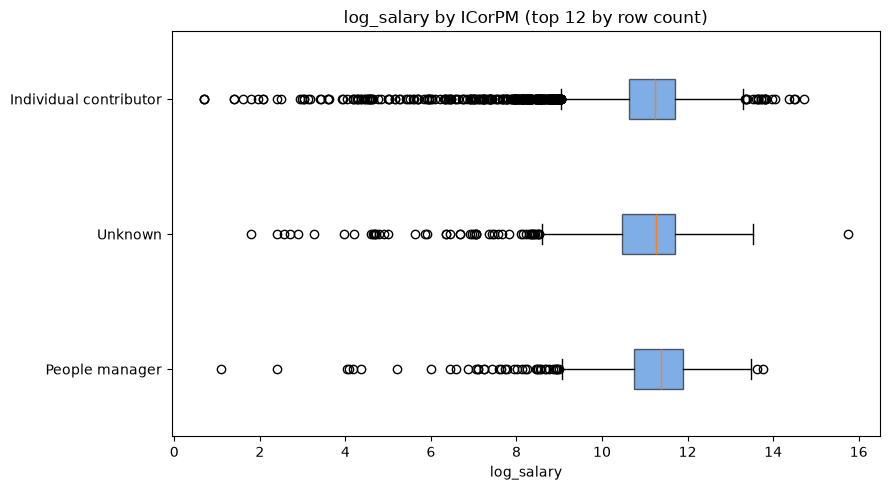

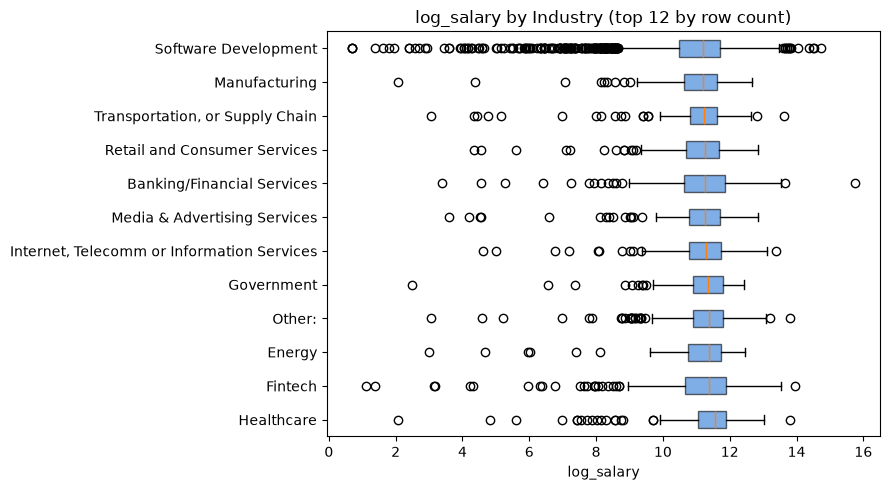

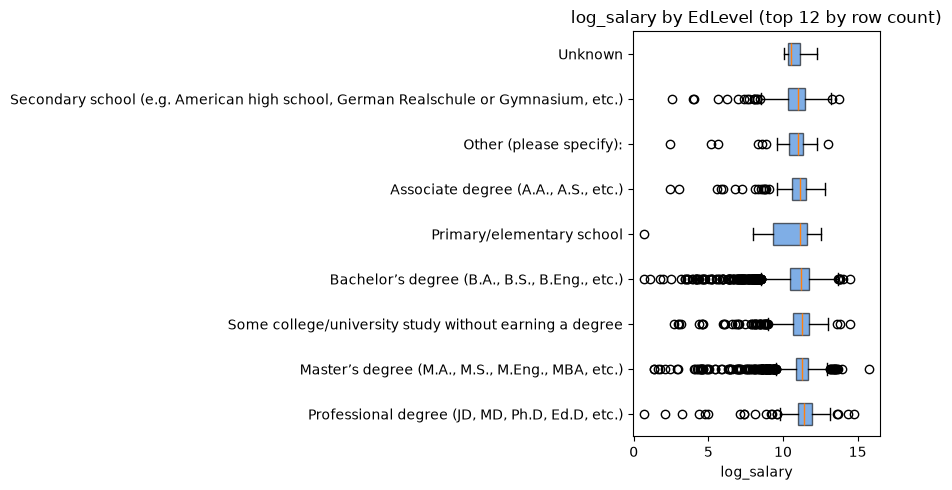

In [11]:
def boxplot_by_category(df, cat_col, value_col="log_salary", top_n=12, ax=None):
    top_cats = df[cat_col].value_counts().nlargest(top_n).index
    sub = df[df[cat_col].isin(top_cats)]
    order = sub.groupby(cat_col)[value_col].median().sort_values(ascending=False).index
    data = [sub.loc[sub[cat_col] == c, value_col].values for c in order]
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 5))
    bp = ax.boxplot(data, orientation="horizontal", patch_artist=True, tick_labels=list(order))
    for box in bp["boxes"]:
        box.set_facecolor(BLUE)
        box.set_alpha(0.6)
    ax.set_xlabel(value_col)
    ax.set_title(f"{value_col} by {cat_col} (top {top_n} by row count)")
    plt.tight_layout()
    return ax


for cat_col in ["DevType", "country_grouped", "RemoteWork", "ICorPM", "Industry", "EdLevel"]:
    boxplot_by_category(clean, cat_col)
    plt.show()


**Reading this:** wide gaps in median position between categories (e.g. `DevType`
or `country_grouped`) are the strongest signal that a categorical feature matters
for salary — a bigger spread here than in `RemoteWork` or `ICorPM` would suggest
country/role dominate over how/whether someone manages people. Wide *boxes* within
one category (not just gaps between categories) also flag where a single category
is hiding a lot of unexplained variance — a candidate for interaction terms or a
model that can pick up nonlinearity (the tree models later).

For `EdLevel` specifically: this is the evidence to check before deciding whether
`Bachelor's degree` should fold into `has_advanced_degree` alongside Master's/
Professional degree (currently used in the `is_usa_x_has_advdeg` interaction in
`02_modeling.ipynb`) — if Bachelor's sits close to Master's/Professional here,
that regrouping has real support; if it sits closer to the no-degree categories,
the current split is already the right one.


### Categorical-categorical associations (Cramér's V)

Pearson correlation doesn't apply between categoricals — this is the equivalent
multicollinearity check for the categorical majority of this dataset.


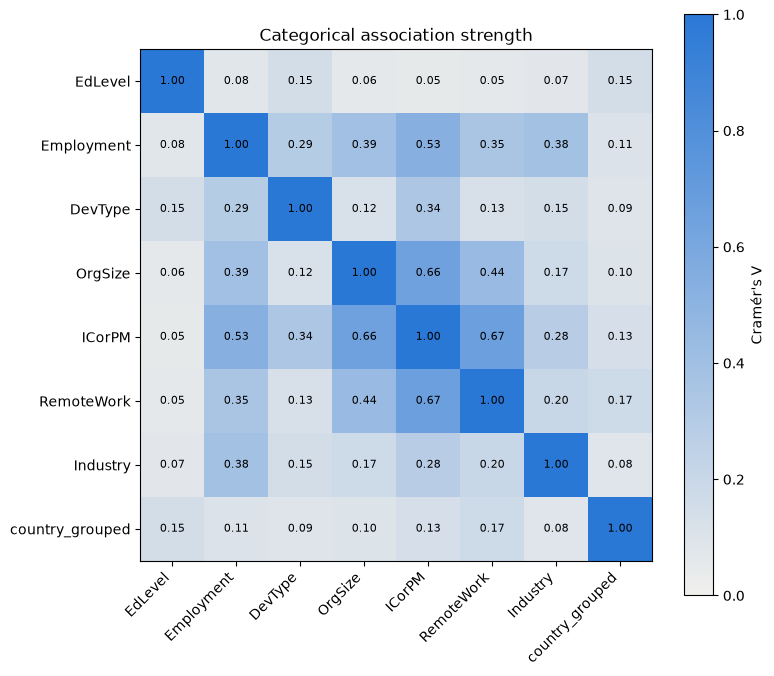

In [12]:
cat_cols = [
    "EdLevel",
    "Employment",
    "DevType",
    "OrgSize",
    "ICorPM",
    "RemoteWork",
    "Industry",
    "country_grouped",
]
n = len(cat_cols)
cv_matrix = pd.DataFrame(np.eye(n), index=cat_cols, columns=cat_cols)
for i in range(n):
    for j in range(i + 1, n):
        v = cramers_v(clean[cat_cols[i]], clean[cat_cols[j]])
        cv_matrix.iloc[i, j] = v
        cv_matrix.iloc[j, i] = v

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cv_matrix, cmap=SEQUENTIAL, vmin=0, vmax=1)
ax.set_xticks(range(n))
ax.set_xticklabels(cat_cols, rotation=45, ha="right")
ax.set_yticks(range(n))
ax.set_yticklabels(cat_cols)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{cv_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="Cram\u00e9r's V")
ax.set_title("Categorical association strength")
plt.tight_layout()
plt.show()


**Reading this:** look for any off-diagonal cell that's notably brighter than the
rest — that's a pair carrying redundant information, the categorical equivalent of
the `WorkExp`/`YearsCode` correlation above. A plausible candidate is `OrgSize` vs
`ICorPM` (bigger orgs are more likely to have formal manager roles) — worth a
specific call on in the modeling notebook if it shows up strongly, the same way
`Country`/`Currency` did in Pass A.


## Summary going into modeling

- `annual_salary_usd`/`log_salary` here are **unwinsorized** — the modeling
  notebook computes outlier bounds from its own train split only and applies
  winsorize+flag there, so it can't leak across train/test/val
- Every categorical NA is now an explicit `"Unknown"` rather than a dropped row
- `Age`/`OrgSize` have both a numeric midpoint and their original ordinal string
- `Country`/`DevType` are grouped into top-N + `"Other"` (`country_grouped`/
  `devtype_grouped`), sized per column by coverage (see `constants.py`)
- `LanguageHaveWorkedWith`/`DatabaseHaveWorkedWith` are expanded into top-N binary
  flags + a count feature (see `data/survey_clean.csv` columns)
- `Currency` is dropped as redundant with `Country`
- `data/survey_clean.csv` is the shared artifact — the modeling notebook and the
  dashboard both read this rather than re-deriving any of the above
